In [ ]:
# Лабораторна робота 8
# Байков Олександр
# Був присутній на парі

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import altair as alt
from sklearn.preprocessing import LabelEncoder


In [16]:
from google.colab import files
uploaded = files.upload()


Saving Sleep_health_and_lifestyle_dataset (1).csv to Sleep_health_and_lifestyle_dataset (1) (1).csv


In [17]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset (1).csv")

In [37]:
# Завдання 1-провести попередній аналіз даних:
# вивести інформацію про датасет
# типи даних
# наявність дублікатів, пропущені значення
print("Типи даних:")
print(df.dtypes)
print("\nНаявність дублікатів:", df.duplicated().sum())
print("\nПропущені значення:")
print(df.isnull().sum())


Типи даних:
Person ID                    int64
Gender                       int64
Age                          int64
Occupation                   int64
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                 int64
Blood Pressure               int64
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder               int64
dtype: object

Наявність дублікатів: 0

Пропущені значення:
Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64


In [38]:
# Завдання 2-перевести типи даних в числові (категоріальні ознаки).
# Вивести оновлений датасет.
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))
    print("\nОновлені типи даних:")
print(df.dtypes)

Person ID                    int64
Gender                       int64
Age                          int64
Occupation                   int64
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                 int64
Blood Pressure               int64
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder               int64
dtype: object


In [39]:
# Завдання 3-Повторна перевірка пропущених значень
print("\nПропущені значення після кодування:")
print(df.isnull().sum())


Пропущені значення після кодування:
Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64


In [40]:
# Завдання 4-Замінити пропущені значення на моду (або середні).
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].mean(), inplace=True)
print(df.isnull().sum())


Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64


In [41]:
# Завдання 5-Вивести статистичні характеристики датасета.
print("\nСтатистичні характеристики:")
print(df.describe())


Статистичні характеристики:
        Person ID      Gender         Age  Occupation  Sleep Duration  \
count  374.000000  374.000000  374.000000  374.000000      374.000000   
mean   187.500000    0.505348   42.184492    3.772727        7.132086   
std    108.108742    0.500641    8.673133    3.056081        0.795657   
min      1.000000    0.000000   27.000000    0.000000        5.800000   
25%     94.250000    0.000000   35.250000    1.000000        6.400000   
50%    187.500000    1.000000   43.000000    3.000000        7.200000   
75%    280.750000    1.000000   50.000000    5.000000        7.800000   
max    374.000000    1.000000   59.000000   10.000000        8.500000   

       Quality of Sleep  Physical Activity Level  Stress Level  BMI Category  \
count        374.000000               374.000000    374.000000    374.000000   
mean           7.312834                59.171123      5.385027      1.296791   
std            1.196956                20.830804      1.774526      1.431

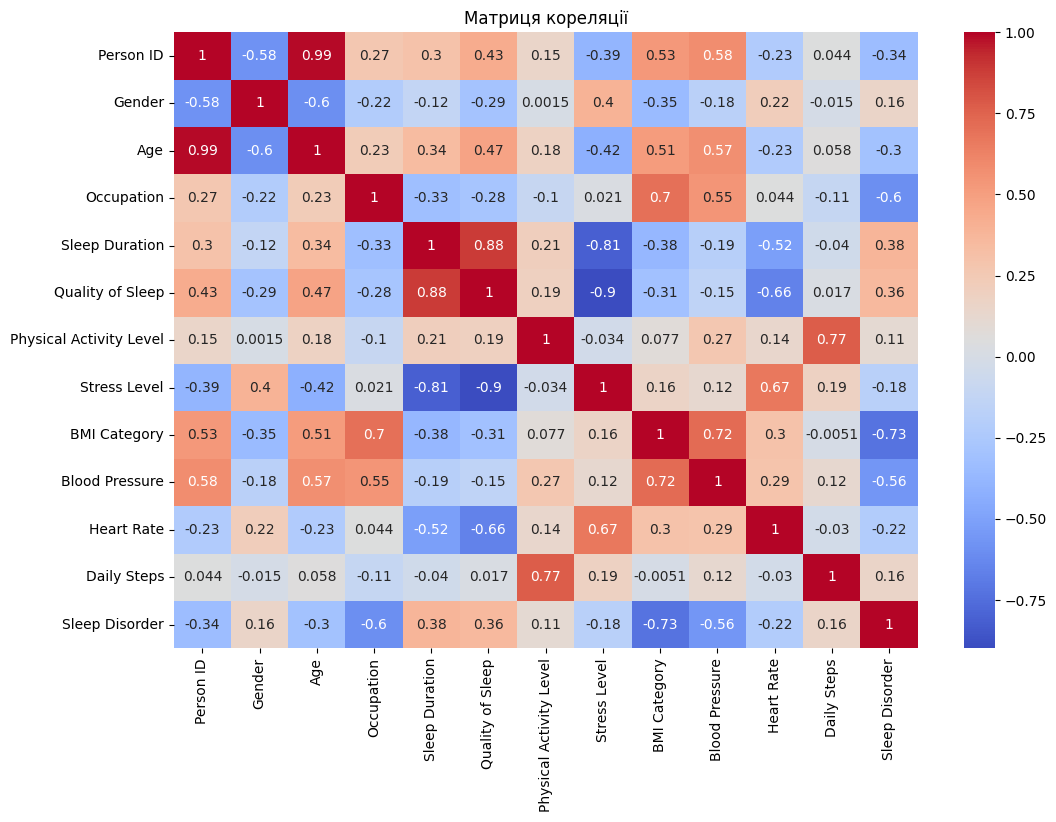

In [42]:
# Завдання 6- Матриця кореляції
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Матриця кореляції")
plt.show()

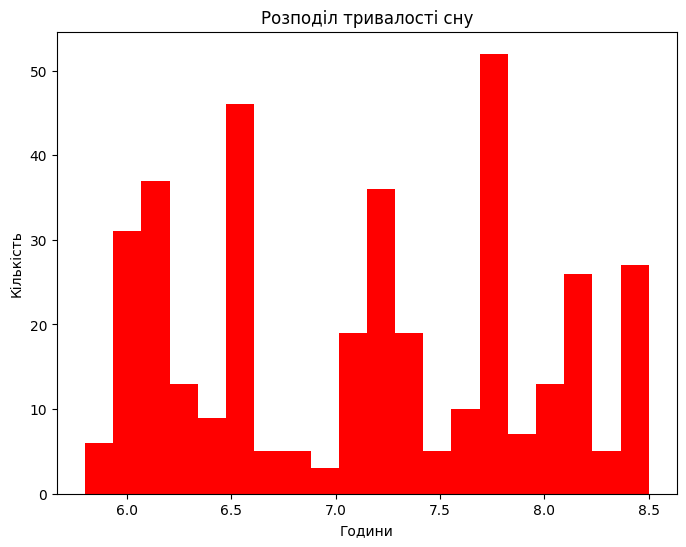

In [43]:
# Завдання 7
plt.figure(figsize=(8,6))
plt.hist(df['Sleep Duration'], bins=20, color='red')
plt.title('Розподіл тривалості сну')
plt.xlabel('Години')
plt.ylabel('Кількість')
plt.show()


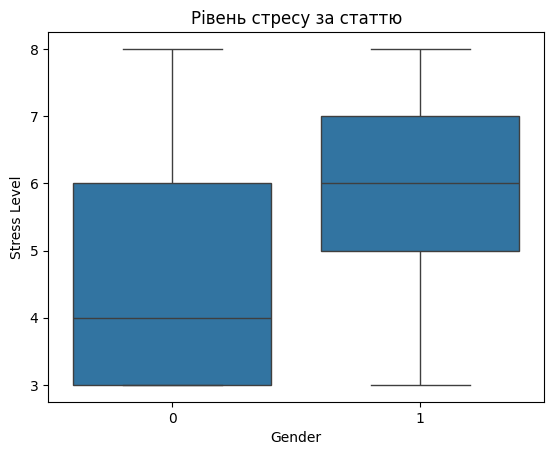

In [44]:
sns.boxplot(x='Gender', y='Stress Level', data=df)
plt.title('Рівень стресу за статтю')
plt.show()


In [45]:
fig = px.scatter(df, x='Age', y='Sleep Duration', color='Sleep Disorder',
                 title='Тривалість сну vs Вік за типом порушення сну')
fig.show()


In [46]:
chart = alt.Chart(df).mark_bar().encode(
    x='Quality of Sleep:Q',
    y='count()',
    color='Gender:N'
).properties(
    title='Якість сну за статтю'
)
chart.display()

alt.Chart(...)

In [36]:
# ВИСНОВКИ
# Завдання 1:
# Проведено попередній аналіз даних: виявлено типи змінних, наявність дублікатів та пропущених значень.
# Завдання 2:
# Категоріальні ознаки були перетворені у числовий формат за допомогою LabelEncoder
# Завдання 3:
# Повторна перевірка пропущених значень після кодування показала, що немає пропущених значень
# Завдання 4:
# Пропущені значення були успішно замінені середніми або модою залежно від типу змінної
# Завдання 5:
# Були виведені статистичні характеристики датасету, що допомогло краще зрозуміти розподіл і варіативність ознак.
# Завдання 6:
# Побудовано матрицю кореляцій, що дозволило виявити залежності між змінними та визначити ключові фактори, які можуть впливати на сон.
# Завдання 7:
# Проведено візуальний аналіз розподілу тривалості сну. За допомогою (matplotlib,seaborn,plotly,altair.)
# Це дало змогу побачити загальну картину щодо звичок сну респондентів.

